In [1]:
# import the data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read csv file as a data frame using pandas
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# discovering the data
# there are three categorical data which we will need to transform later
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# discovering the data
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


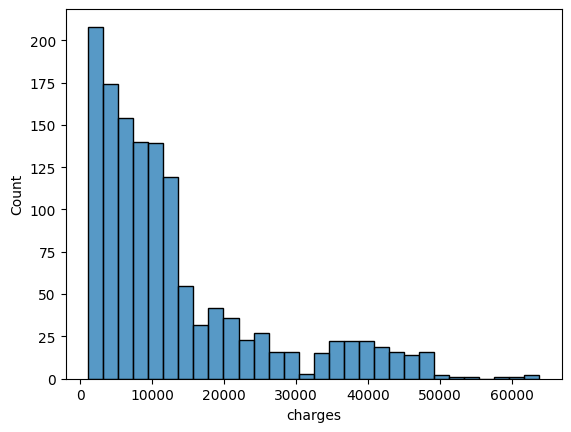

In [5]:
# discovering the data
# most people pay for the minimum charges
sns.histplot(df['charges']);

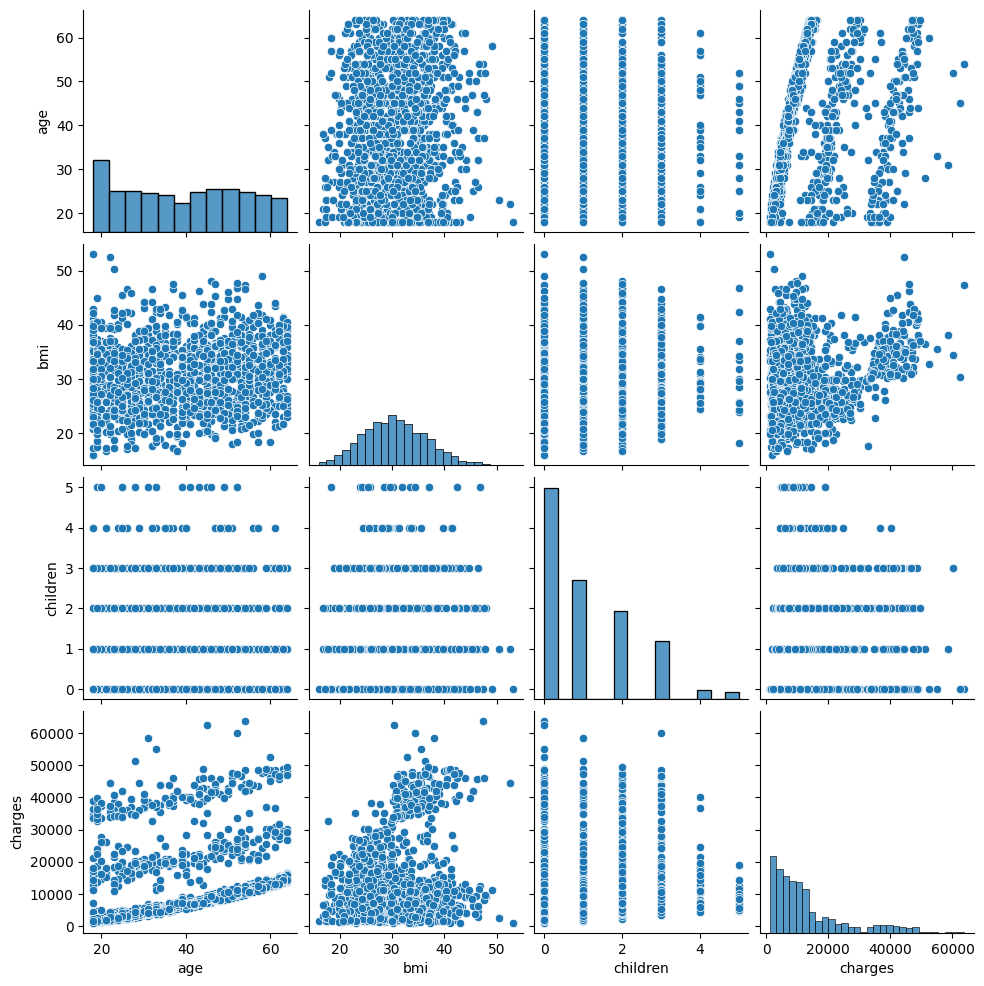

In [6]:
# discovering the data
# there is positive correlation between age and insurance charges
# most paying people are people with BMI higher than 30
sns.pairplot(df);

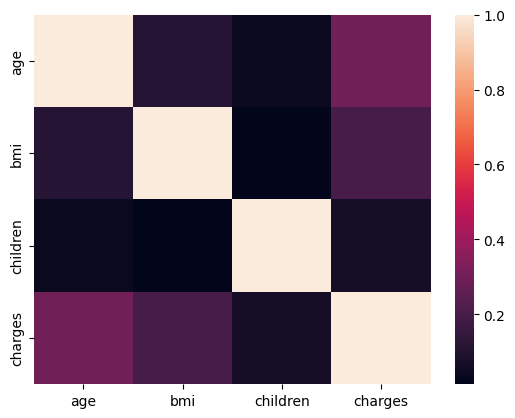

In [7]:
# discovering the data
# there is a relationship between charges and ages
sns.heatmap(df.select_dtypes('number').corr());

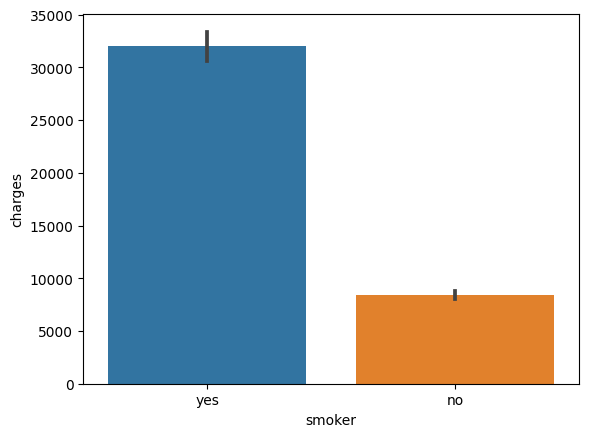

In [8]:
# discovering the data
# smoders apears to pay a lot more than non-smokers
sns.barplot(data= df,x='smoker', y='charges');

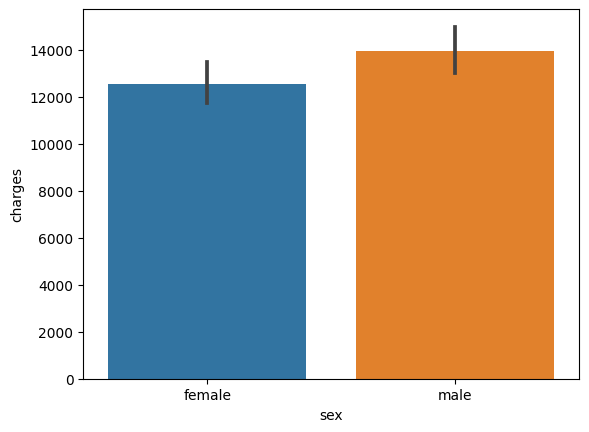

In [9]:
# discovering the data
# men pay slightly more than women
sns.barplot(data= df,x='sex', y='charges');

In [10]:
# transforming the categorical data into numerical data so the model can read them
df = pd.get_dummies(df, columns = ['sex','smoker','region'])
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [11]:
# splitting the data into features(x) and target(y)
x= df.drop('charges', axis=1)
y= df['charges']

In [12]:
# splitting the features(x) and target(y) into train data(70%) and test data(30%)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=23)

In [13]:
# training the model using the Linear Regression algorithm
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train,y_train)

LinearRegression()

In [14]:
lm.intercept_

-588.5082822360891

In [15]:
# testing the model
prediction = lm.predict(x_test)
prediction

array([ 1.15556107e+04,  6.43938529e+03,  3.17035575e+04,  1.00893128e+04,
        8.13729512e+03,  9.37016411e+03,  3.57068320e+04,  8.50952037e+03,
        1.28688019e+04,  3.96245087e+04,  1.64154106e+03,  3.70496382e+04,
        4.27807733e+03,  1.23222943e+04,  8.20636146e+03,  5.15411211e+03,
        5.21851105e+03,  3.57137501e+03,  3.53349447e+04,  3.33162949e+04,
        3.90530484e+04,  1.35743547e+04,  8.16597066e+03,  9.76483836e+03,
        3.58416498e+04,  6.92358530e+03,  5.23644462e+03,  2.93582960e+04,
        4.30248707e+02,  1.14011526e+04,  1.37335207e+04,  4.83630607e+03,
        3.85330841e+03,  1.20308959e+04,  8.85687908e+03,  2.91631343e+04,
        1.11799466e+04,  1.06381579e+04,  9.74602336e+03,  4.45951474e+03,
        1.08900543e+04,  3.43128518e+04,  1.12135752e+04,  3.18981391e+04,
        1.11912228e+04,  1.36132266e+04,  4.28239602e+03,  5.46876965e+03,
        8.76643214e+03,  5.34116889e+03,  1.35420171e+04,  8.85981521e+03,
        1.04195188e+04,  

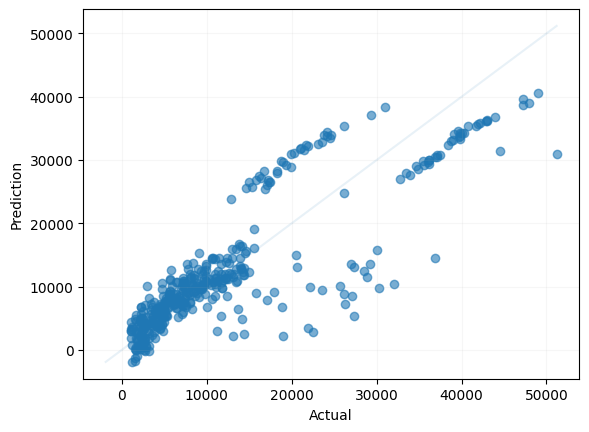

In [16]:
# showing the difference between the prediction and the actual data
plt.scatter(y_test, prediction,alpha = 0.6);
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.grid(alpha = 0.1)
maxmum = max(max(y_test), max(prediction))
minmum = min(min(y_test), min(prediction))
plt.plot([maxmum,minmum], [maxmum,minmum], alpha = 0.1);

In [17]:
# testing the accuracy of the model
# the model explains approximately 73% of the variance in the data
from sklearn import metrics
print(metrics.mean_absolute_error(y_test, prediction))
print(metrics.mean_squared_error(y_test, prediction))
print(np.sqrt(metrics.mean_squared_error(y_test, prediction)))
print(metrics.r2_score(y_test, prediction))

4040.515150394454
35313304.808081135
5942.499878677419
0.7292924601639751
